# Some preliminary analysis plotting

In [1]:
from otter import Otter
import otter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

from astropy import units as u
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coord

from scipy.stats import kstest

db = Otter('.otter')

In [2]:
# read in the metadata so we know what to query for
meta = pd.read_csv('ecle-meta-data.csv')

phot_radio = db.get_phot(names=meta.name.tolist(), flux_unit='mJy', freq_unit='GHz', return_type='pandas', obs_type='radio')
phot_uvoir = db.get_phot(names=meta.name.tolist(), flux_unit='mag(AB)', wave_unit='nm', return_type='pandas', obs_type='uvoir')
phot = db.get_phot(names=meta.name.tolist(), flux_unit='mJy', freq_unit='GHz', return_type='pandas')

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:621: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:621: UserWarning: Unable to apply the source mapping because '2020MNRAS.499..482N,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:621: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/.local

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


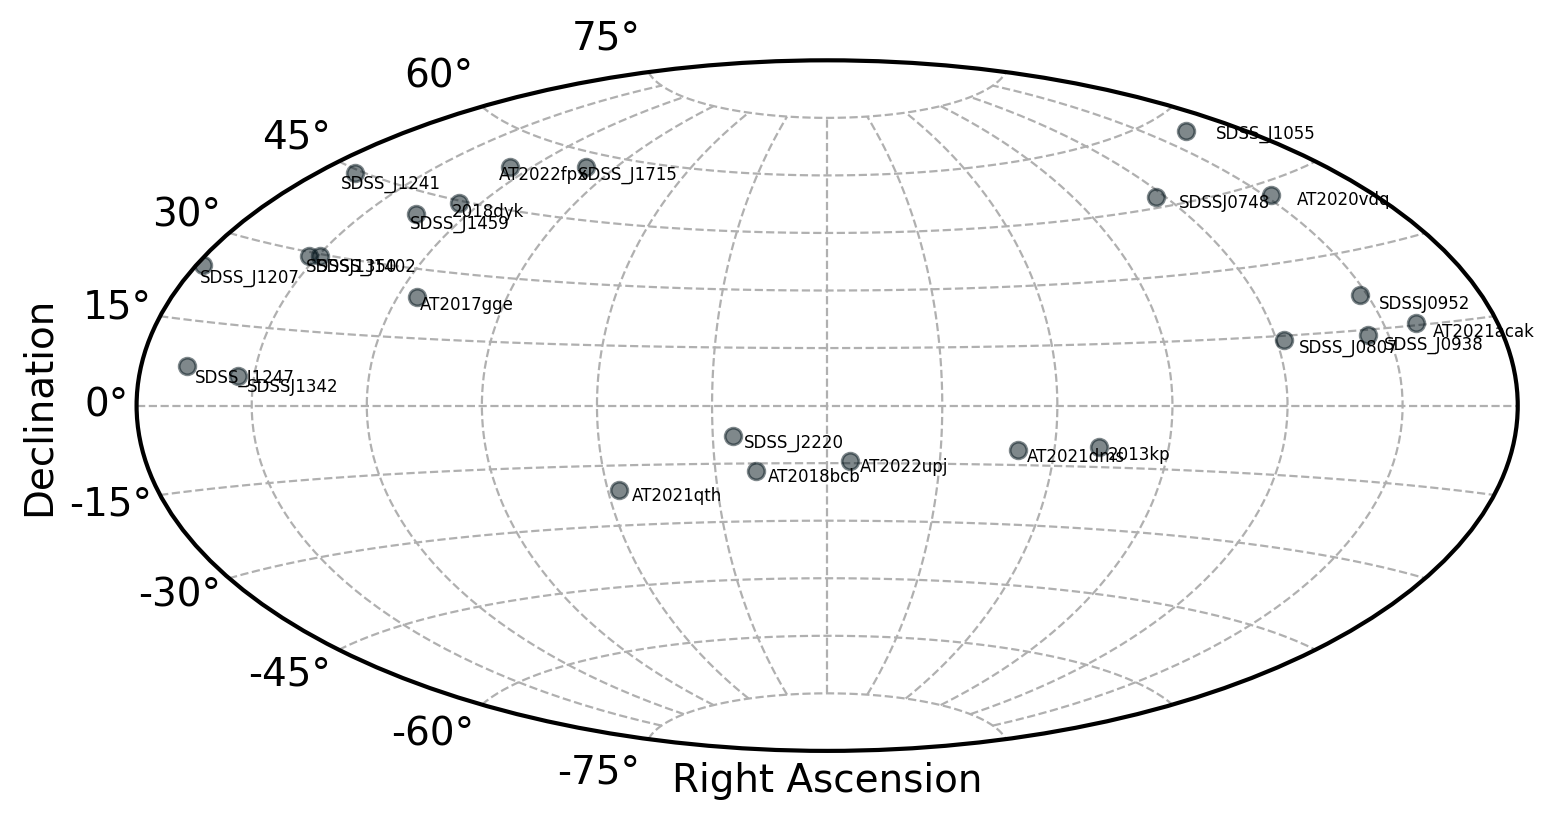

In [3]:
# generate a coordinate plot of these and overlay the wise regions

allmeta = db.get_meta(names=list(meta.name))
coordinates = coord.SkyCoord([t.get_skycoord() for t in allmeta])
names = [m.default_name for m in allmeta]

ra = coord.Angle(coordinates.ra)
dec = coord.Angle(coordinates.dec)

ra = ra.wrap_at(180*u.deg)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="aitoff")

ax.plot(ra.radian, dec.radian, 'o', alpha=0.5)

for r,d,n in zip(ra,dec,names):
    ax.text(r.radian+0.05,d.radian-0.05,n,fontdict={'fontsize':6})

ax.grid()
ax.set_xticklabels([])
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
_=ax.legend(loc='lower right')

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:621: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:621: UserWarning: Unable to apply the source mapping because '2020MNRAS.499..482N,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:757: RuntimeWarning: invalid value encountered in multiply
  flux_err = np.multiply(flux, np.divide(q_err.value, q.value))


Text(0.5, 0, 'MJD')

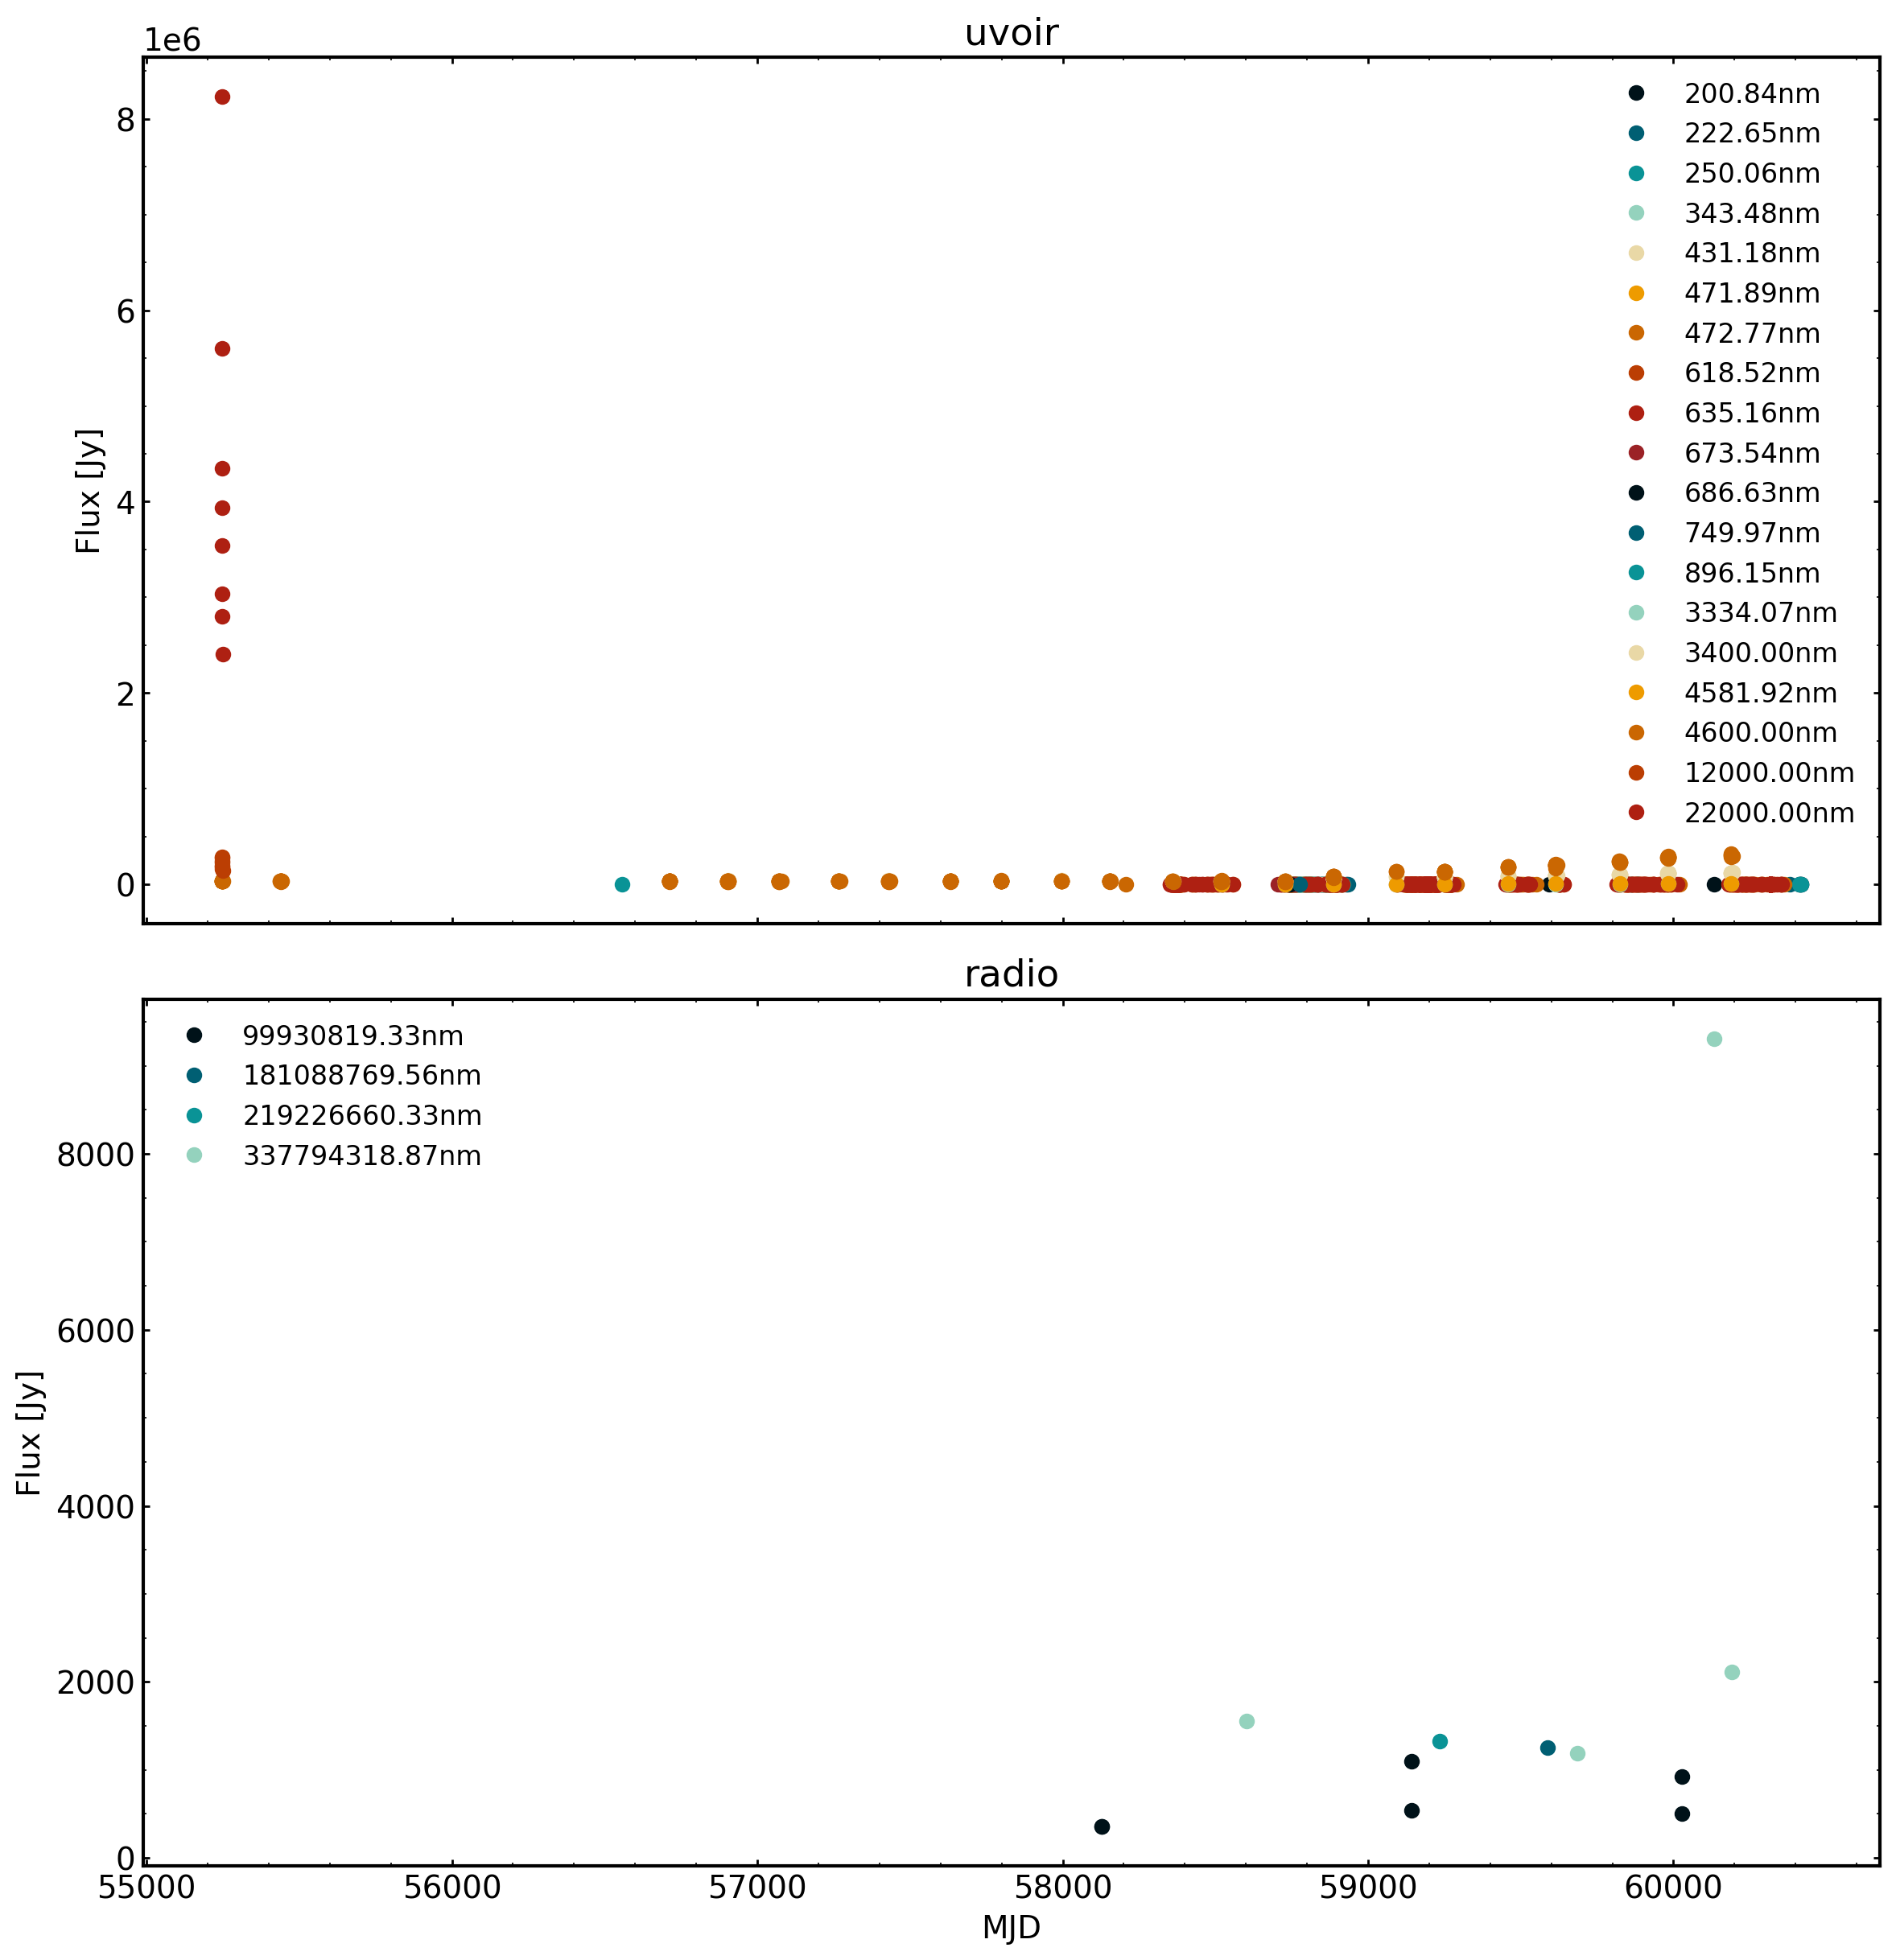

In [4]:
tde_name = '2019qiz'

fig, ax = plt.subplots(3,1, sharex=True, figsize=(12,18))

for ii, obs_type in enumerate(['xray','uvoir','radio']):
    
    try:
        df = db.get_phot(names=tde_name, return_type='pandas', 
                     flux_unit='uJy', obs_type=obs_type)
    except otter.exceptions.FailedQueryError:
        fig.delaxes(ax[ii])
        continue
    
    for label, grp in df.groupby('converted_wave'):

        # if not pd.isna(grp.converted_flux_err.iloc[0]):
        #     ax[ii].errorbar(
        #         grp.converted_date, 
        #         grp.converted_flux, 
        #         yerr=grp.converted_flux_err, 
        #         label=f'{label:.2f}nm',
        #         linestyle='none'
        #     )
        # else:
        ax[ii].plot(
            grp.converted_date, 
            grp.converted_flux,
            label=f'{label:.2f}nm',
            marker='o',
            linestyle='none'
        )

    ax[ii].set_title(obs_type)
    
    ax[ii].set_ylabel('Flux [Jy]')
    
    ax[ii].legend(fontsize=12)

ax[-1].set_xlabel('MJD')

# Let's just plot some radio light curves of all of these

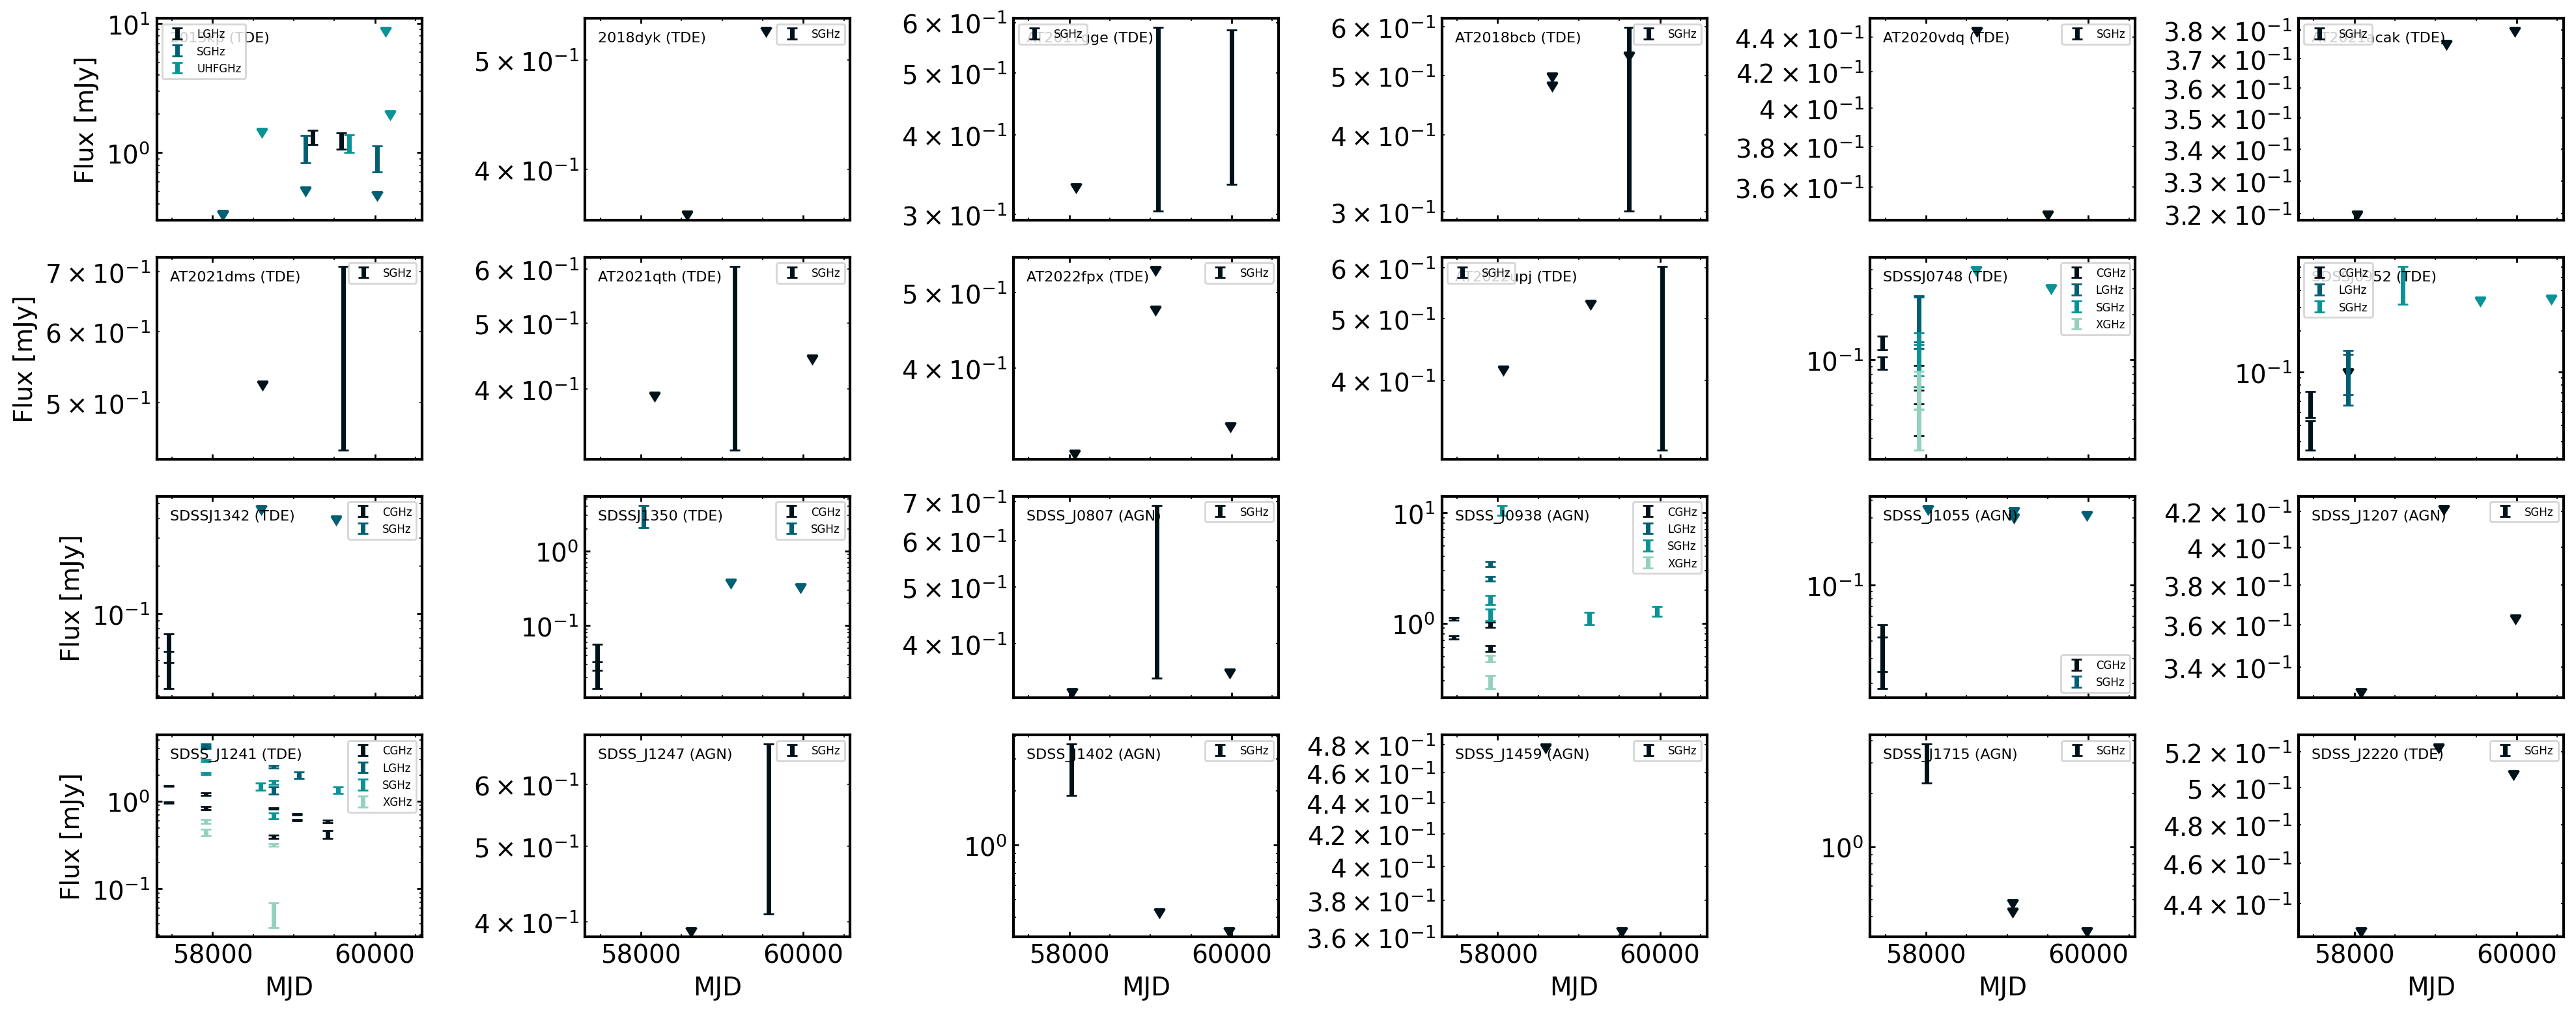

In [24]:
radio = phot_radio

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=True)

flat_axs = axs2d.flatten() 

for idx, ((name, data), ax) in enumerate(zip(radio.groupby('name'), flat_axs)):

    for label, grp in data.groupby('filter_name'):
        ax.errorbar(
            grp.converted_date,
            grp.converted_flux, 
            yerr=grp.converted_flux_err,
            label=f'{label}GHz',
            linestyle='none',
            # marker='o',
            uplims=grp.upperlimit
        )
    
    if not idx%6:
        ax.set_ylabel('Flux [mJy]')
    
    if idx >= 18:
        ax.set_xlabel('MJD')
        
    ax.set_yscale('log')
        
    #ax.text(ax.get_xlim()[0], ax.get_ylim()[1]-ax.get_ylim()[1]//2, name)
    
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
        
    at = AnchoredText(f'{name} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=8))
    ax.add_artist(at)
    
    ax.legend(fontsize=6, frameon=True, fancybox=True)
    # ax.set_xscale('log')


# Look at some of the SEDs

In [6]:
def make_sed(tde_name, ax):
    classes = db.query(names=tde_name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]

    for label, grp in df.groupby('converted_date'):

        ax.errorbar(
            grp.converted_freq, 
            grp.converted_flux,
            fmt='o',
            markersize=3,
            yerr=grp.converted_flux_err,
            label=f'{label:.2f} MJD',
            uplims=grp.upperlimit
        )

        next(ax._get_lines.prop_cycler)['color']


    ax.set_ylabel('Flux [Jy]')
    ax.set_xlabel('Frequency [GHz]')
    ax.set_

    at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
    ax.add_artist(at)

    ax.legend(fontsize=12)

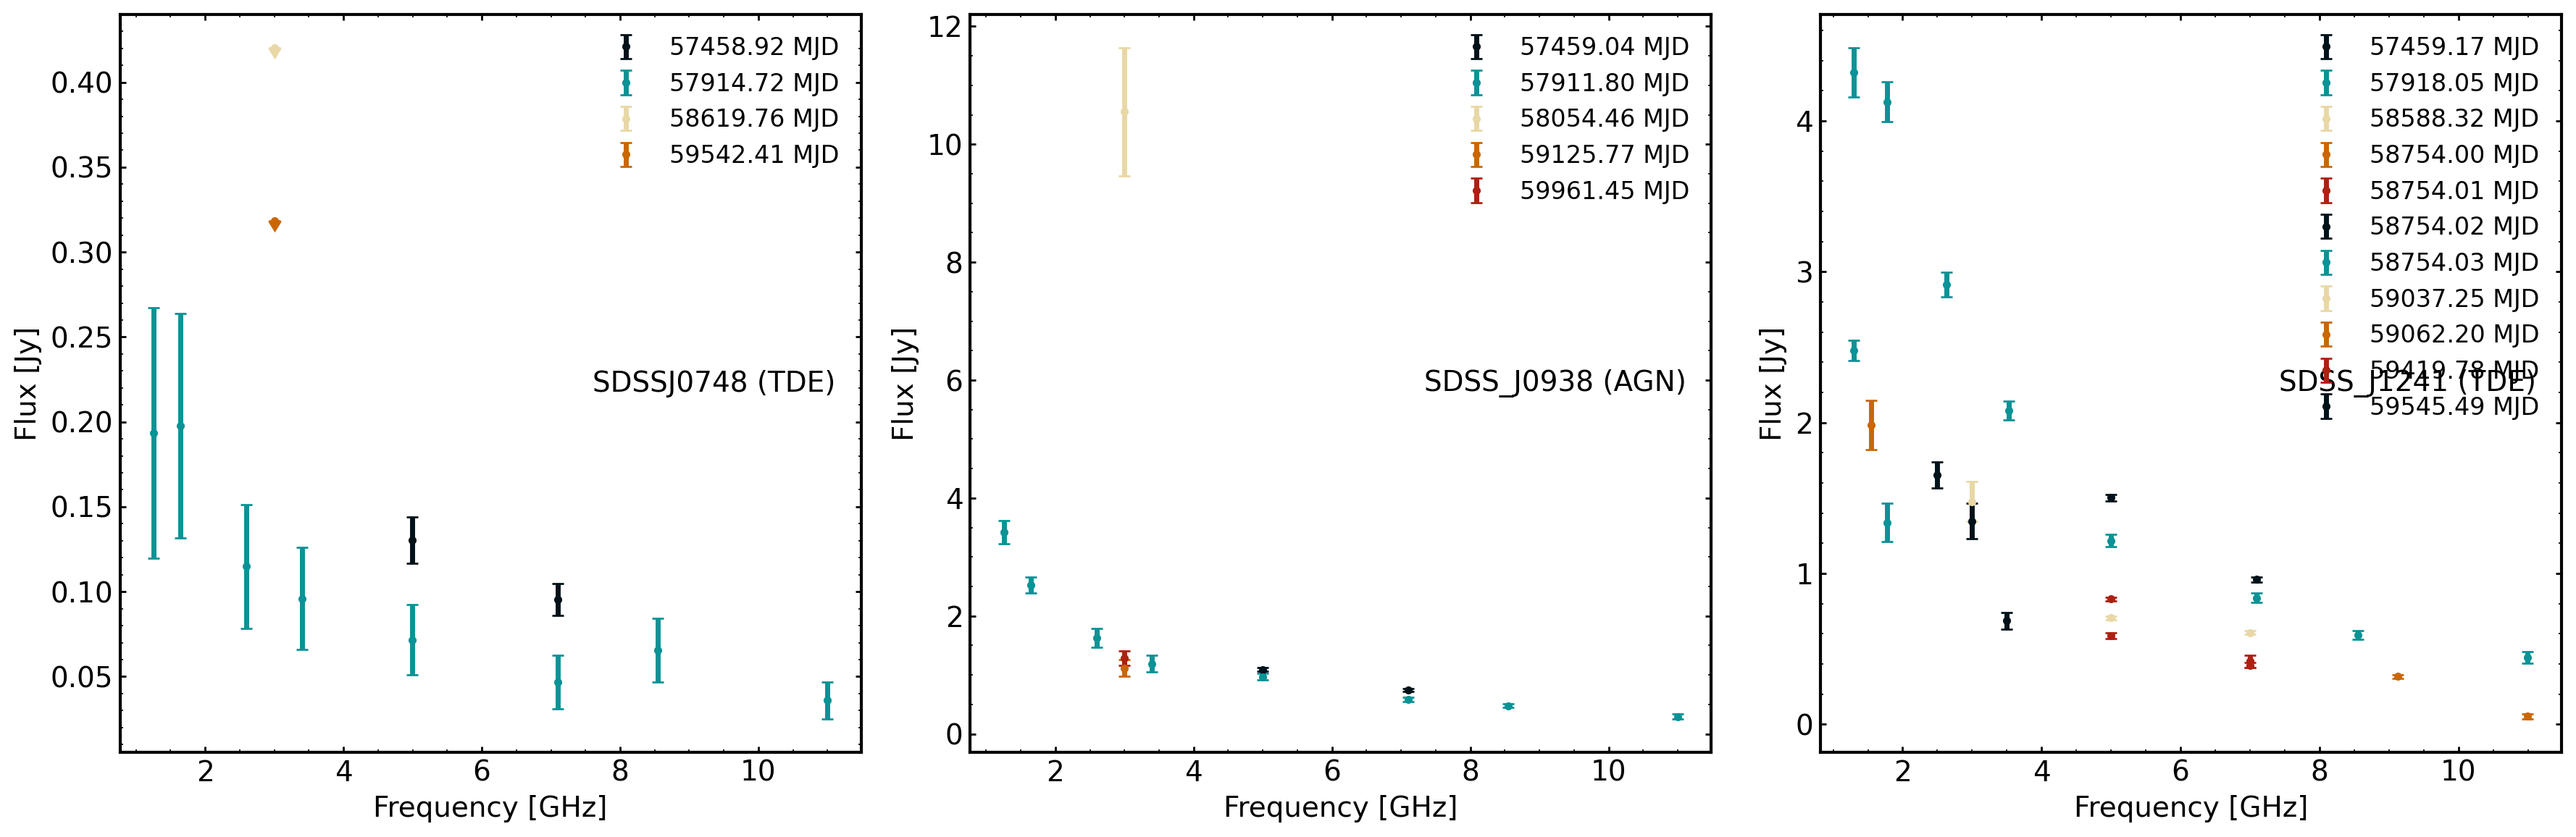

In [7]:
ecles_with_good_seds = ['SDSSJ0748','SDSS_J0938','SDSS_J1241']
fig, axs = plt.subplots(1,len(ecles_with_good_seds), figsize=(18,6))
                        
for ii, tde_name in enumerate(ecles_with_good_seds):
    make_sed(tde_name, axs[ii])

# Plot the WISE Light Curves

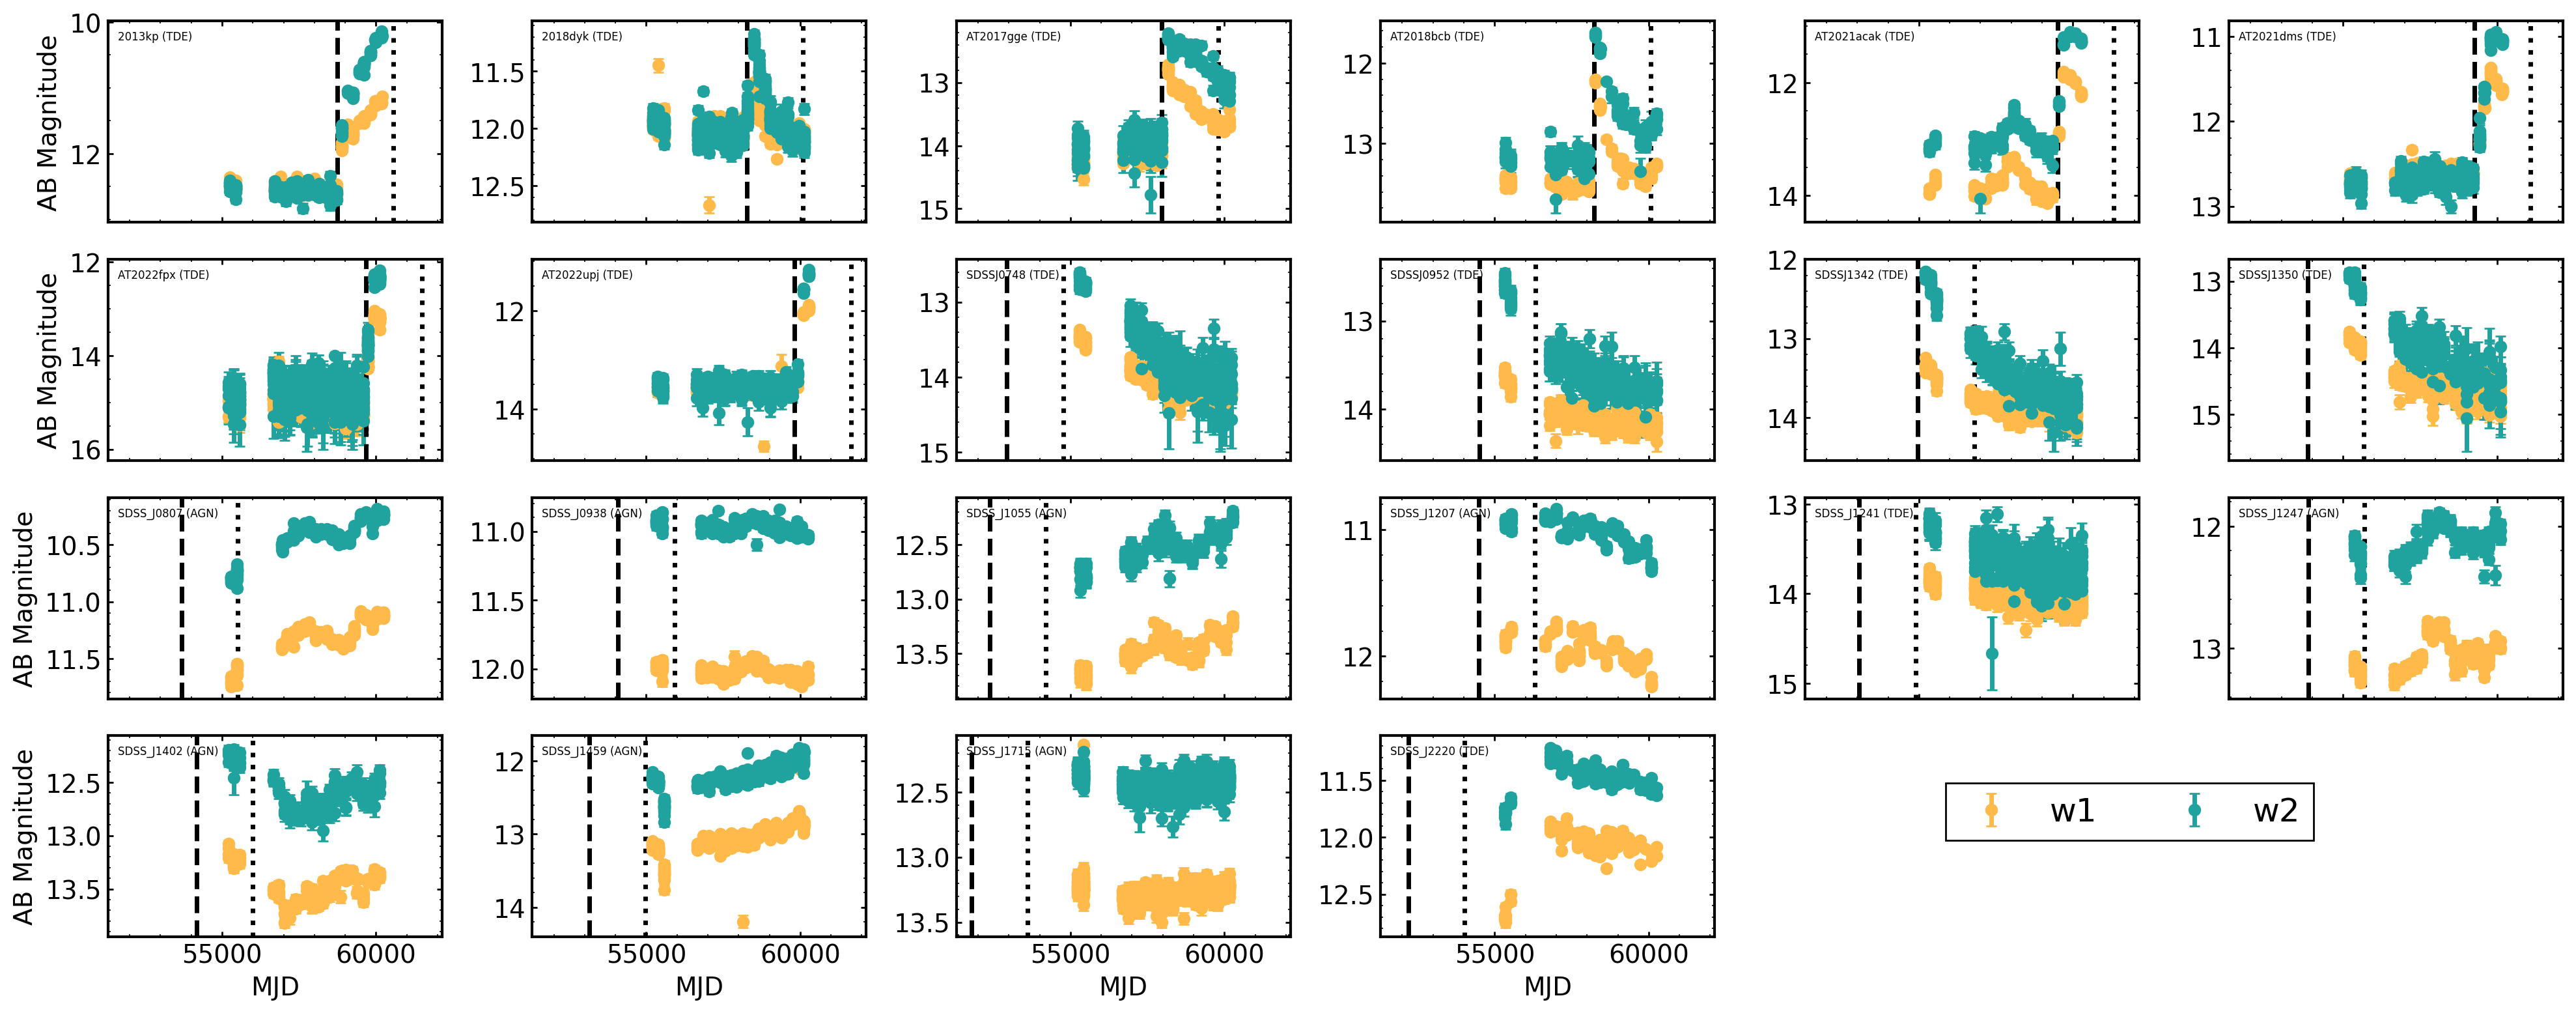

In [8]:
wise = phot_uvoir

color_map = {'w1':'#ffba49',
             'w2': '#20a39e',
             'w3': '#ef5b5b',
             'w4': 'k'}

filters_to_plot = {'w1', 'w2'}

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=True)

flat_axs = axs2d.flatten() 

for idx, ((name, data), ax) in enumerate(zip(wise.groupby('name'), flat_axs)):

    for f,d in data.groupby('filter_name'):
        if f not in filters_to_plot: continue
        if idx == 0: 
            label = f
        else:
            label = None
        ax.errorbar(
            d.converted_date, 
            d.converted_flux, 
            yerr=d.converted_flux_err, 
            color=color_map[f], 
            marker='o', 
            linestyle='none', 
            label=label
        )
        
    ax.invert_yaxis()

    if not idx%6:
        ax.set_ylabel('AB Magnitude')
    
    if idx >= 18:
        ax.set_xlabel('MJD')
        
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    
    try:
        discovery_date = db.get_meta(names=name)[0].get_discovery_date()
        ax.axvline(discovery_date.mjd, linestyle='--', color='k')        
        ax.axvline(discovery_date.mjd+365*5, linestyle=':', color='k')        
    except: pass # this is fine it just means we don't have a discovery date
    
    at = AnchoredText(f'{name} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=6))
    ax.add_artist(at)
    
for ax in flat_axs[idx+1:]:
    ax.remove()
    
fig.legend(fontsize=18, bbox_to_anchor=(0.9,0.25), ncol=2, frameon=True, edgecolor='k', framealpha=1, fancybox=False);

# Some statistical tests with the WISE data

In [10]:
# compute the "dust echo flux"

bands = {
    'w1':3.4*u.um,
    'w2':4.6*u.um,
    'w3':12*u.um,
    'w4':22*u.um
} # in um

def flux_to_luminosity(flux, lum_dist):
    return (4*np.pi*lum_dist**2 * flux).to(u.erg/u.s)

def flux_to_abs_mag(flux, lum_dist, band):
    '''
    Convert the flux to the absolute magnitude
    '''
    lum0 = {
        'w1': flux_to_luminosity(
            (3631.00*u.Jy).to(
                u.erg/u.s/u.cm**2, 
                equivalencies=u.spectral_density(bands[band])
            ), 
            lum_dist
        ),
        'w2': flux_to_luminosity(
            (3631.00*u.Jy).to(
                u.erg/u.s/u.cm**2, 
                equivalencies=u.spectral_density(bands[band])
            ),
            lum_dist
        )
    }
    
    lum = flux_to_luminosity(flux, lum_dist)
    absmag = -2.5*np.log10(lum/lum0[band])
    
    return absmag

dust_echo_time = 5*365 # 5 years to days

dust_echo_data = {
    'name' : [],
    'w1_flux' : [],
    'w1_lum_mean' : [],
    'w1_lum_max' : [],
    'w1_lum_diff' : [],
    'w2_flux': [],
    'w2_lum_mean' : [],
    'w2_lum_max' : [],
    'w2_lum_diff' : [],
    'class' : [],
    'discovery_date' : []
}

for name, data in wise.groupby('name'):
    
    # some cosmological calculations
    # z = meta[meta.name==name].redshift # redshift
    z = db.get_meta(names=name)[0].get_redshift()
    lum_dist = cosmo.luminosity_distance(z) # the luminosity distance from the redshift
    
    dust_echo_data['name'].append(name)
    
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    dust_echo_data['class'].append(ecle_class)
    
    disc_date = db.get_meta(names=name)[0].get_discovery_date().mjd
    dust_echo_data['discovery_date'].append(disc_date)

    echo_data = data[(data.converted_date > disc_date) * (data.converted_date < disc_date+dust_echo_time)]
    
    # first W1
    max_mag_w1 = np.min(echo_data[echo_data.filter_name=='w1'].converted_flux, axis=0) * u.Unit('mag(AB)')
    mean_mag_w1 = np.mean(data[data.filter_name=='w1'].converted_flux, axis=0) * u.Unit('mag(AB)')
    if pd.isna(max_mag_w1):
        # first soften the time constraints
        echo_data_soft = data[(data.converted_date > disc_date)]
        
        # then we just take the first point in the dataset
        max_mag_w1 = echo_data_soft[echo_data_soft.filter_name=='w1'].converted_flux.values[0] * u.Unit('mag(AB)')
        
    mean_flux_w1 = mean_mag_w1.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w1']))
    mean_lum_w1 = flux_to_abs_mag(mean_flux_w1, lum_dist, 'w1')
    max_flux_w1 = max_mag_w1.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w1']))
    max_lum_w1 = flux_to_abs_mag(max_flux_w1, lum_dist, 'w1')
    
    dust_echo_data['w1_flux'].append(mean_flux_w1.value)
    dust_echo_data['w1_lum_mean'].append(mean_lum_w1.value)
    dust_echo_data['w1_lum_max'].append(max_lum_w1.value)
    dust_echo_data['w1_lum_diff'].append(max_lum_w1.value - mean_lum_w1.value)
    
    # then W2
    max_mag_w2 = np.min(echo_data[echo_data.filter_name=='w2'].converted_flux, axis=0) * u.Unit('mag(AB)') # "max" is really min in mag space
    mean_mag_w2 = np.mean(data[data.filter_name=='w2'].converted_flux, axis=0) * u.Unit('mag(AB)')
    if pd.isna(max_mag_w2):
        # first soften the time constraints
        echo_data_soft = data[(data.converted_date > disc_date)]
        
        # then we just take the first point in the dataset
        max_mag_w2 = echo_data_soft[echo_data_soft.filter_name=='w1'].converted_flux.values[0] * u.Unit('mag(AB)')
    
    mean_flux_w2 = mean_mag_w2.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w2']))
    mean_lum_w2 = flux_to_abs_mag(mean_flux_w2, lum_dist, 'w2')
    max_flux_w2 = max_mag_w2.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w2']))
    max_lum_w2 = flux_to_abs_mag(max_flux_w2, lum_dist, 'w2')
    
    dust_echo_data['w2_flux'].append(mean_flux_w2.value)
    dust_echo_data['w2_lum_mean'].append(mean_lum_w2.value)
    dust_echo_data['w2_lum_max'].append(max_lum_w2.value)
    dust_echo_data['w2_lum_diff'].append(max_lum_w2.value - mean_lum_w2.value)
    
dust_echo_df = pd.DataFrame(dust_echo_data)

dust_echo_df

,name,w1_flux,w1_lum_mean,w1_lum_max,w1_lum_diff,w2_flux,w2_lum_mean,w2_lum_max,w2_lum_diff,class,discovery_date
0,2013kp,4.351728e-11,12.166766,11.132066,-1.034700,4.030691e-11,11.921774,10.143066,-1.778709,TDE,58745.499803
1,2018dyk,5.079592e-11,11.998848,11.593066,-0.405782,3.968428e-11,11.938677,11.171066,-0.767611,TDE,58269.310000
2,AT2017gge,1.008905e-11,13.753795,12.711066,-1.042729,1.086559e-11,13.345090,12.211066,-1.134024,TDE,57968.349988
3,AT2018bcb,1.505167e-11,13.319458,12.204066,-1.115393,1.677970e-11,12.873262,11.624066,-1.249196,TDE,58235.120000
4,AT2021acak,1.370093e-11,13.421545,11.809066,-1.612480,2.067904e-11,12.646397,11.103066,-1.543331,TDE,59509.620000
5,AT2021dms,3.409497e-11,12.431694,11.167066,-1.264629,2.605095e-11,12.395664,10.953066,-1.442598,TDE,59266.145706
6,AT2022fpx,3.651396e-12,14.857273,13.047066,-1.810207,3.569023e-12,14.553849,12.187066,-2.366784,TDE,59669.519810
7,AT2022upj,1.369833e-11,13.421751,11.881066,-1.540685,1.116072e-11,13.315992,11.167066,-2.148927,TDE,59822.378000
8,SDSSJ0748,7.606872e-12,14.060405,13.427066,-0.633339,7.650075e-12,13.726059,13.427066,-0.298993,TDE,52935.000000
9,SDSSJ0952,7.584127e-12,14.063656,13.531066,-0.532590,9.579050e-12,13.481917,12.454066,-1.027851,TDE,54501.000000


Text(0.5, 0, 'W1-W2')

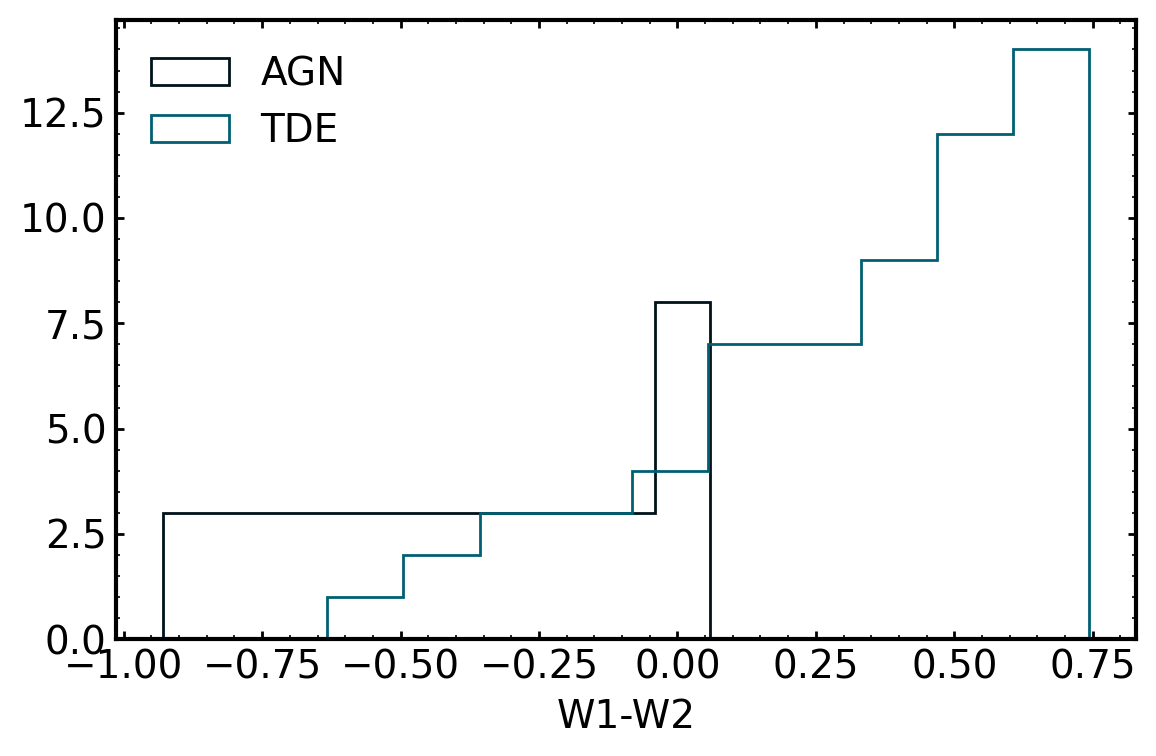

In [11]:
########################################
### Key to compute stats by
key = '_lum_diff'
key_w1 = 'w1'+key
key_w2 = 'w2'+key
##########################################

fig, ax = plt.subplots(1,1, figsize=(6,4))

agn = dust_echo_df[dust_echo_df['class'] == 'AGN']
tde = dust_echo_df[dust_echo_df['class'] == 'TDE']

ax.hist(agn[key_w1]-agn[key_w2], histtype='step', cumulative=True, label='AGN')
ax.hist(tde[key_w1]-tde[key_w2], histtype='step', cumulative=True, label='TDE')
ax.legend()
# ax2.hist(agn.w2_mean_lum, histtype='step', cumulative=True)
# ax2.hist(tde.w2_mean_lum, histtype='step', cumulative=True)

ax.set_xlabel('W1-W2')

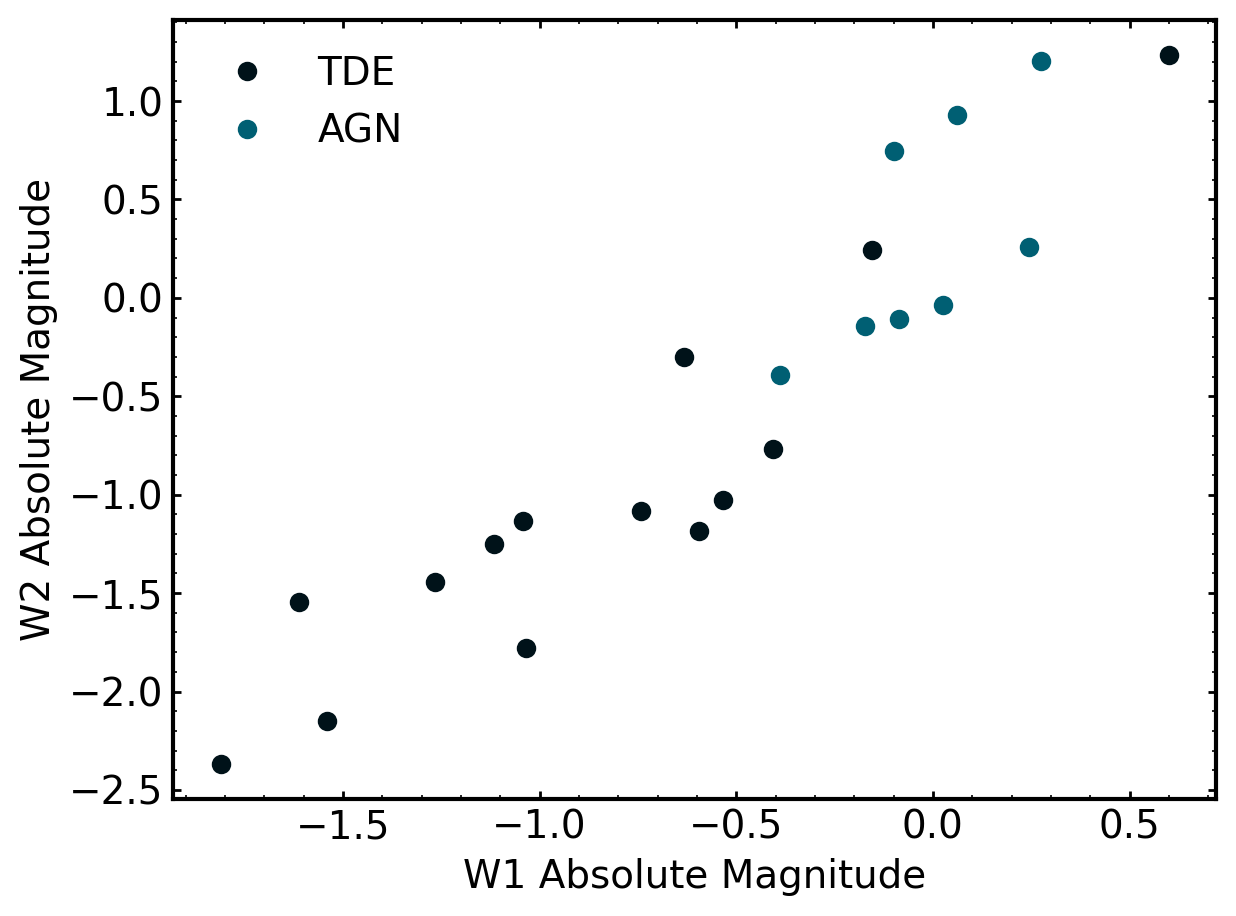

In [12]:
fig,ax = plt.subplots()

ax.plot(tde[key_w1], tde[key_w2], label='TDE', marker='o', linestyle='none')
ax.plot(agn[key_w1], agn[key_w2], label='AGN', marker='o', linestyle='none')

ax.set_xlabel('W1 Absolute Magnitude')
ax.set_ylabel('W2 Absolute Magnitude')

ax.legend()

In [13]:
res_w1 = kstest(tde[key_w1], agn[key_w1])
res_w2 = kstest(tde[key_w2], agn[key_w2])
res_w2_minus_w1 = kstest(tde[key_w1]-tde[key_w2], agn[key_w1]-agn[key_w2])

print(f'W1 p-value   : {res_w1.pvalue}\nW2 p-value   : {res_w2.pvalue}\nW1-W2 p-value: {res_w2_minus_w1.pvalue}')

W1 p-value   : 0.00035650623885918
W2 p-value   : 0.0015823873409012733
W1-W2 p-value: 0.0058166807392813595


# Compare Radio and IR properties

In [14]:
radio_class = []
for name, wise_data in dust_echo_df.groupby('name'):
    radio_phot = db.get_phot(names=name, obs_type='radio', return_type='pandas')
    radio_phot = radio_phot[radio_phot.converted_date > wise_data.discovery_date.values[0]] # we only care about detections after discovery
    is_radio_bright = np.any(radio_phot.upperlimit == False)
    radio_class.append(is_radio_bright)
    
dust_echo_df['is_radio_bright'] = radio_class

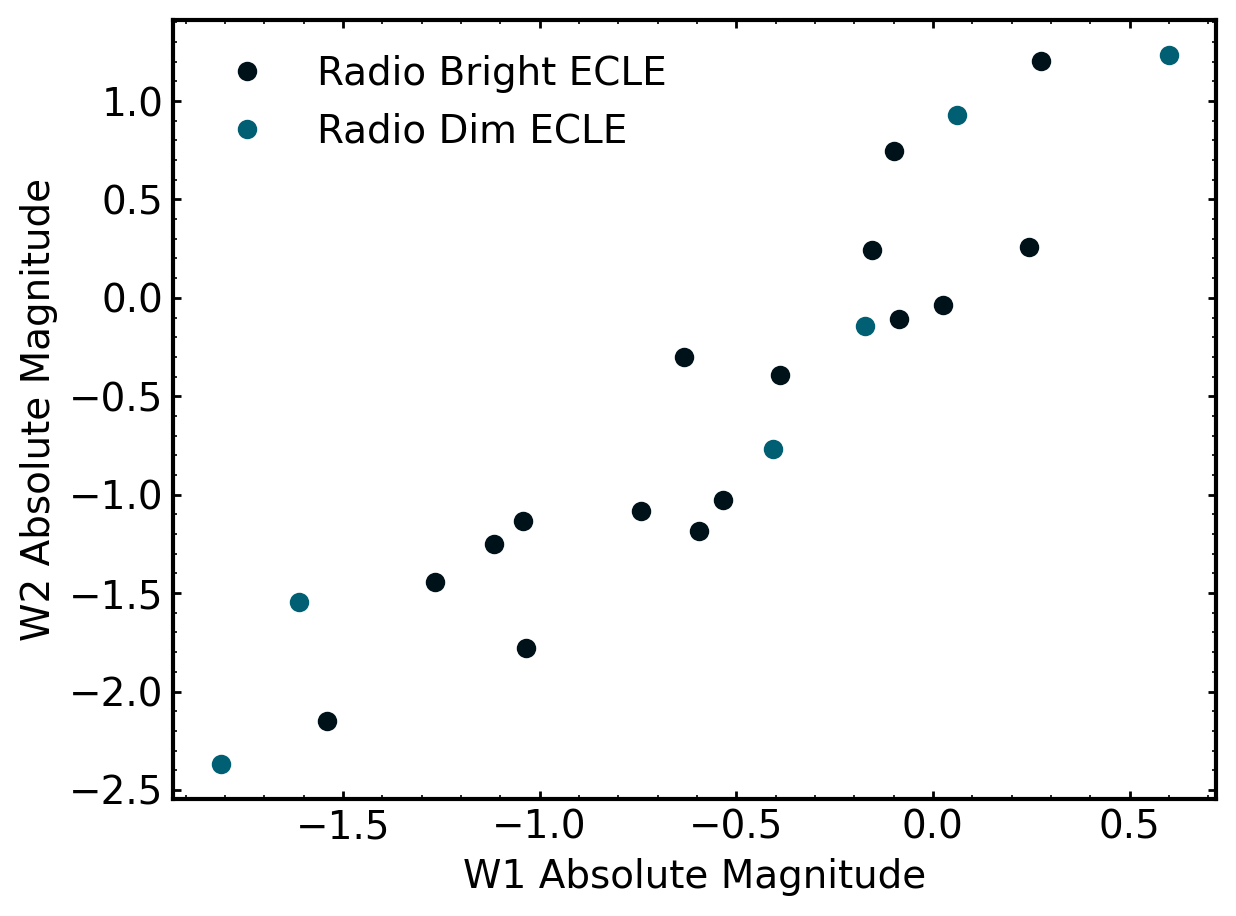

In [15]:
radio_bright = dust_echo_df[dust_echo_df.is_radio_bright]
radio_dim = dust_echo_df[~dust_echo_df.is_radio_bright]

fig,ax = plt.subplots()

ax.plot(radio_bright[key_w1], radio_bright[key_w2], label='Radio Bright ECLE', marker='o', linestyle='none')
ax.plot(radio_dim[key_w1], radio_dim[key_w2], label='Radio Dim ECLE', marker='o', linestyle='none')

ax.set_xlabel('W1 Absolute Magnitude')
ax.set_ylabel('W2 Absolute Magnitude')

ax.legend()

Text(0.5, 0, 'W1 - W2')

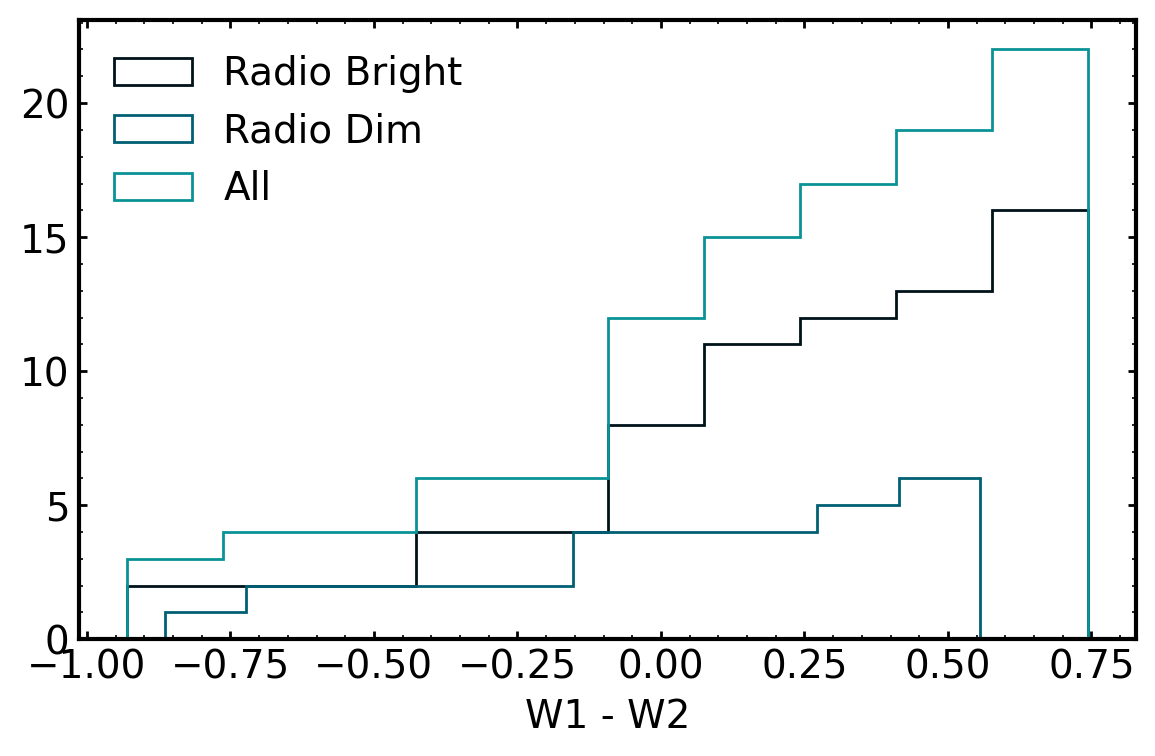

In [16]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

ax.hist(radio_bright[key_w1]-radio_bright[key_w2], histtype='step', cumulative=True, label='Radio Bright')
ax.hist(radio_dim[key_w1]-radio_dim[key_w2], histtype='step', cumulative=True, label='Radio Dim')
ax.hist(dust_echo_df[key_w1]-dust_echo_df[key_w2], histtype='step', cumulative=True, label='All')
ax.legend()
# ax2.hist(agn.w2_mean_lum, histtype='step', cumulative=True)
# ax2.hist(tde.w2_mean_lum, histtype='step', cumulative=True)

ax.set_xlabel('W1 - W2')

In [17]:
# All ECLEs
res_w1 = kstest(radio_bright[key_w1], radio_dim[key_w1])
res_w2 = kstest(radio_bright[key_w2], radio_dim[key_w2])
res_w2_minus_w1 = kstest(radio_bright[key_w1]-radio_bright[key_w2], radio_dim[key_w1]-radio_dim[key_w2])

print(f'W1 p-value: {res_w1.pvalue}\nW2 p-value: {res_w2.pvalue}\nW1-W2 p-value: {res_w2_minus_w1.pvalue}')

W1 p-value: 0.6171042579711309
W2 p-value: 0.8359937276345945
W1-W2 p-value: 0.34522134212536687


In [18]:
# Just the TDEs

bright_tdes = radio_bright[radio_bright['class'] == 'TDE']
dim_tdes = radio_dim[radio_dim['class'] == 'TDE']

res_w1 = kstest(bright_tdes[key_w1], dim_tdes[key_w1])
res_w2 = kstest(bright_tdes[key_w2], dim_tdes[key_w2])
res_w2_minus_w1 = kstest(bright_tdes[key_w1]-bright_tdes[key_w2], dim_tdes[key_w1]-dim_tdes[key_w2])

print(f'W1 p-value: {res_w1.pvalue}\nW2 p-value: {res_w2.pvalue}\nW1-W2 p-value: {res_w2_minus_w1.pvalue}')

W1 p-value: 0.40959040959040954
W2 p-value: 0.9190809190809193
W1-W2 p-value: 0.9190809190809193


Text(0.5, 0, 'Number of ECLEs')

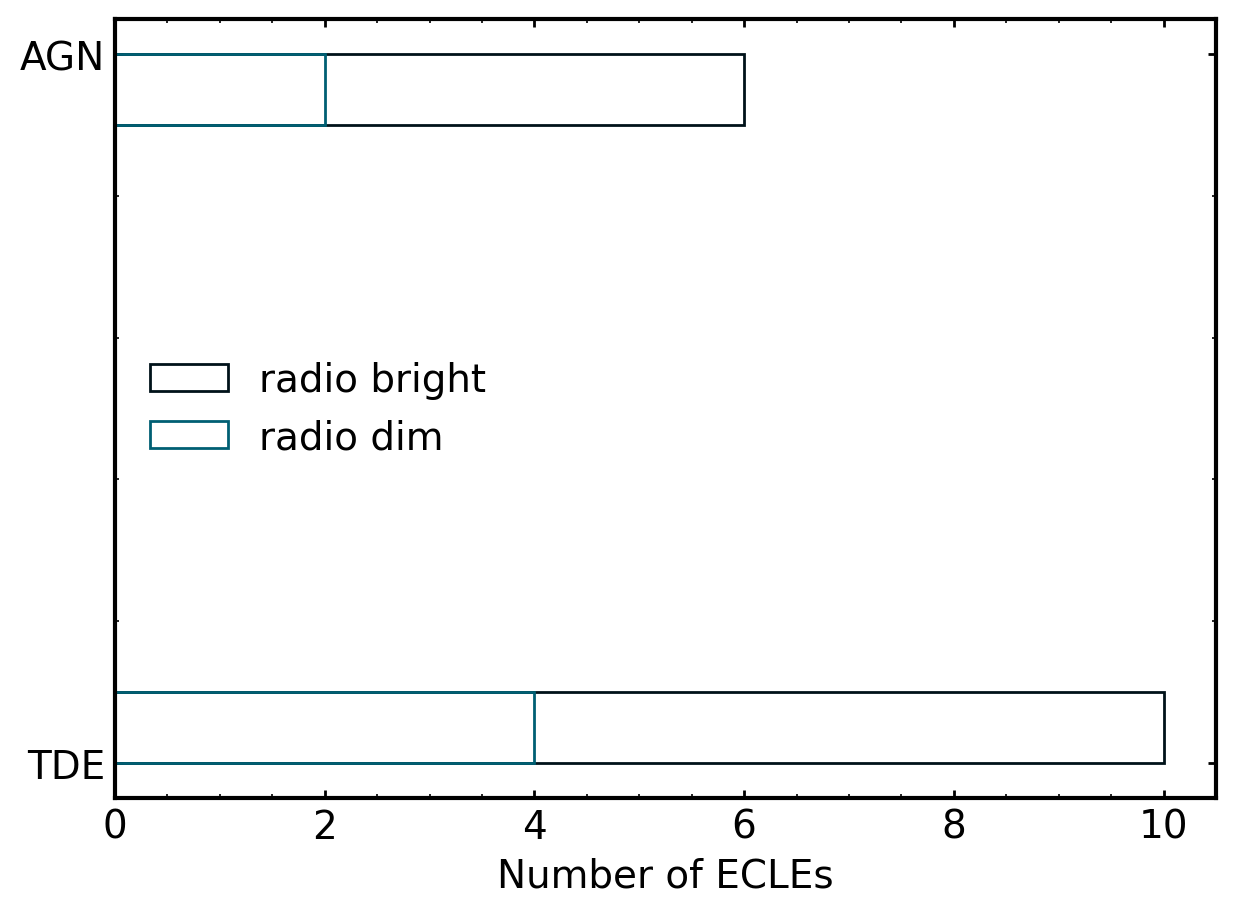

In [19]:
fig,ax = plt.subplots()
ax.hist(radio_bright['class'], label='radio bright', histtype='step', orientation='horizontal')
ax.hist(radio_dim['class'], label='radio dim', histtype='step', orientation='horizontal')

ax.legend(loc='center left')

ax.set_xlabel('Number of ECLEs')

In [20]:
res = kstest(radio_bright['class'], radio_dim['class'])

res.pvalue

1.0

In [21]:
dust_echo_df

,name,w1_flux,w1_lum_mean,w1_lum_max,w1_lum_diff,w2_flux,w2_lum_mean,w2_lum_max,w2_lum_diff,class,discovery_date,is_radio_bright
0,2013kp,4.351728e-11,12.166766,11.132066,-1.034700,4.030691e-11,11.921774,10.143066,-1.778709,TDE,58745.499803,True
1,2018dyk,5.079592e-11,11.998848,11.593066,-0.405782,3.968428e-11,11.938677,11.171066,-0.767611,TDE,58269.310000,False
2,AT2017gge,1.008905e-11,13.753795,12.711066,-1.042729,1.086559e-11,13.345090,12.211066,-1.134024,TDE,57968.349988,True
3,AT2018bcb,1.505167e-11,13.319458,12.204066,-1.115393,1.677970e-11,12.873262,11.624066,-1.249196,TDE,58235.120000,True
4,AT2021acak,1.370093e-11,13.421545,11.809066,-1.612480,2.067904e-11,12.646397,11.103066,-1.543331,TDE,59509.620000,False
5,AT2021dms,3.409497e-11,12.431694,11.167066,-1.264629,2.605095e-11,12.395664,10.953066,-1.442598,TDE,59266.145706,True
6,AT2022fpx,3.651396e-12,14.857273,13.047066,-1.810207,3.569023e-12,14.553849,12.187066,-2.366784,TDE,59669.519810,False
7,AT2022upj,1.369833e-11,13.421751,11.881066,-1.540685,1.116072e-11,13.315992,11.167066,-2.148927,TDE,59822.378000,True
8,SDSSJ0748,7.606872e-12,14.060405,13.427066,-0.633339,7.650075e-12,13.726059,13.427066,-0.298993,TDE,52935.000000,True
9,SDSSJ0952,7.584127e-12,14.063656,13.531066,-0.532590,9.579050e-12,13.481917,12.454066,-1.027851,TDE,54501.000000,True


In [22]:
def compute_decision_boundary(X, clf, ax=None, n=1000, idxs_to_plot=(0,1)):
    
    ndim = X.shape[1] # this is the number of dimensions accepted by the clf
    
    invals = np.array([np.linspace(X[:,i].min()-0.5, X[:,i].max()+0.5, n) for i in range(ndim)])
    
    if ax is None:
        _, ax = plt.subplots()
        
    x, y = np.meshgrid(
        invals[idxs_to_plot[0]],
        invals[idxs_to_plot[1]]
    )
        
    predicted = [clf.predict(np.array(list(x)+list(y)+list(v)).reshape(-1, 1)) for x,y,v in zip(x,y,list(invals[2:].T)*len(x))]
    c = ax.contourf(x, y, predicted, cmap='bone_r')
    return c

/tmp/ipykernel_339252/1834139115.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_radio_bright'] = data.is_radio_bright.astype(int)


ValueError: X has 1 features, but DecisionTreeClassifier is expecting 7 features as input.

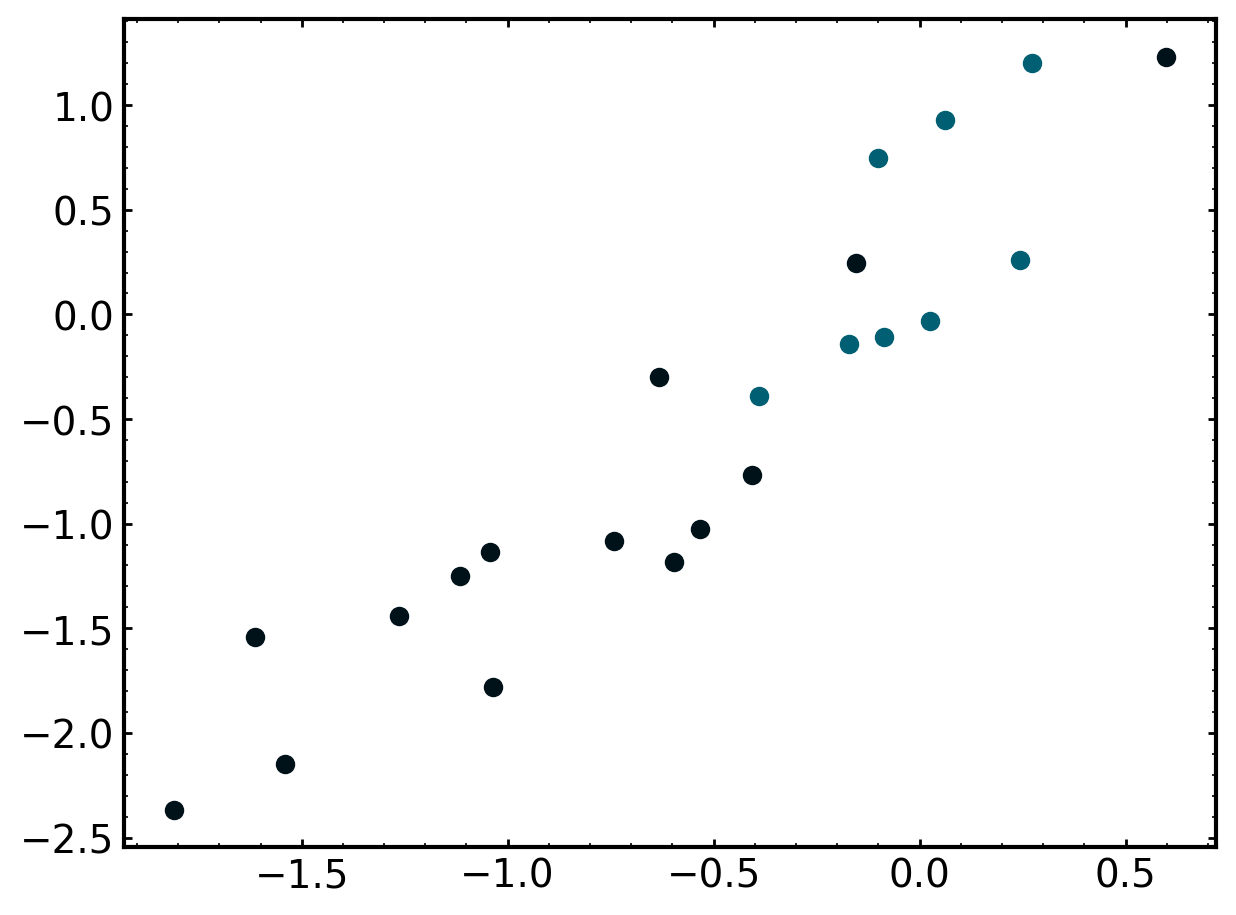

In [23]:
# see what cut a classifier gives this data

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

label_map = {'TDE': 0, 'AGN': 1}

keys_to_keep = ['w1_lum_mean', 'w1_lum_max', 'w1_lum_diff', 'w2_lum_mean', 'w2_lum_max', 'w2_lum_diff', 'is_radio_bright']
plot_keys = keys_to_keep[:2]

data = dust_echo_df[keys_to_keep]
data['is_radio_bright'] = data.is_radio_bright.astype(int)
targ = dust_echo_df['class'].replace(label_map)

clf = DecisionTreeClassifier()
clf.fit(data, targ)

# plot_tree(clf);


fig,ax = plt.subplots()

ax.plot(tde[key_w1], tde[key_w2], label='TDE', marker='o', linestyle='none')
ax.plot(agn[key_w1], agn[key_w2], label='AGN', marker='o', linestyle='none')

c = compute_decision_boundary(data.values, clf, ax=ax)

ax.set_xlabel('True W1 Absolute Magnitude')
ax.set_ylabel('True W2 Absolute Magnitude')

ax.legend()


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
cmappable = ScalarMappable(norm=Normalize(0,1), cmap=c.cmap)
cbar = fig.colorbar(cmappable, ax=ax, ticks=[0,1], label='Classifier Prediction')
cbar.ax.set_yticklabels(['TDE', 'AGN']) 